In [1]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import math
import tiktoken
import torch
import torch.nn as nn

In [ ]:
"""
This notebook is to illustrate the Transformer architecture.
Steps are followed by my article post:
https://waylandzhang.github.io/en/let-s-code-llm.html
"""

'\nThis notebook is to illustrate the Transformer architecture.\nSteps are followed by my article post: \nhttps://waylandzhang.github.io/en/let-s-code-llm.html\n'

In [2]:
# Hyperparameters
batch_size = 4  # How many batches per training step
context_length = 16  # Length of the token chunk each batch
d_model = 64  # The vector size of the token embeddings
num_layers = 8  # Number of transformer blocks
num_heads = 4  # Number of heads in Multi-head attention # 我们的代码中通过 d_model / num_heads = 来获取 head_size
learning_rate = 1e-3  # 0.001
dropout = 0.1 # Dropout rate
max_iters = 500  # Total of training iterations
eval_interval = 50  # How often to evaluate the model
eval_iters = 20  # How many iterations to average the loss over when evaluating the model
device = 'cuda' if torch.cuda.is_available() else 'cpu'  # Instead of using the cpu, we'll use the GPU if it's available.

TORCH_SEED = 1337
torch.manual_seed(TORCH_SEED)

In [5]:
# download a sample txt file from https://huggingface.co/datasets/goendalf666/sales-textbook_for_convincing_and_selling/raw/main/sales_textbook.txt
if not os.path.exists('data/sales_textbook.txt'):
    url = 'https://huggingface.co/datasets/goendalf666/sales-textbook_for_convincing_and_selling/raw/main/sales_textbook.txt'
    with open('sales_textbook.txt', 'w') as f:
        f.write(requests.get(url).text)

with open('sales_textbook.txt', 'r', encoding='utf-8') as f:
    text = f.read()


In [6]:
# Using TikToken to tokenize the source text
encoding = tiktoken.get_encoding("cl100k_base")
tokenized_text = encoding.encode(text)
tokenized_text = torch.tensor(tokenized_text, dtype=torch.long, device=device) # Convert tokens into a tensor
max_token_value = tokenized_text.max().item() # the maximum index value in our vocabulary

print(f"Tokenized text size: {len(tokenized_text)}")
print(f"The maximum value in the tokenized text is: {max_token_value}")

Tokenized text size: 77919
The maximum value in the tokenized text is: 100069


In [7]:
# Illustration purpose
print(encoding.encode('Chapter 1: Building Rapport and Capturing'))
print(encoding.decode([26072, 220, 16, 25, 17283, 23097, 403, 323, 17013, 1711])) # "Rapport" is tokenized as two tokens: "Rap"[23097] and "port"[403]
print(encoding.decode([627, 1383, 88861, 279,1989, 315, 25607, 16940, 65931, 323, 32097, 11, 584, 26458, 13520, 449]))

[26072, 220, 16, 25, 17283, 23097, 403, 323, 17013, 1711]
Chapter 1: Building Rapport and Capturing
.
By mastering the art of identifying underlying motivations and desires, we equip ourselves with


In [8]:
# Split train and validation
split_idx = int(len(tokenized_text) * 0.9)
train_data = tokenized_text[:split_idx]
val_data = tokenized_text[split_idx:]

In [9]:
# Prepare data for training batch
data = train_data
idxs = torch.randint(low=0, high=len(data) - context_length, size=(batch_size,))
x_batch = torch.stack([data[idx:idx + context_length] for idx in idxs])
y_batch = torch.stack([data[idx + 1:idx + context_length + 1] for idx in idxs])
print(x_batch.shape, x_batch.shape)

torch.Size([4, 16]) torch.Size([4, 16])


In [10]:
# Illustration purpose
pd.set_option('display.expand_frame_repr', False)
print("Our batches:\n", pd.DataFrame(x_batch.data.detach().cpu().numpy()))

Our batches:
       0      1     2      3     4      5      6      7      8      9    10     11     12     13     14     15
0    279   6763  1920     13   578   5845    311  13750  19570    279  907    323   7720    315   1057   3956
1   3495  14955    11    477  5064  23146    430   9788    279  66732  315    701  10209     13   3296  32644
2  38769  10742    11  20958   264   6928  19451     11  11125  64784   11    323  56501  54111    439   6975
3  43496    872  8830    719  1101   3727    279   6130   2733   6755  323  16365    627  29831  19682   5900


In [11]:
# Define Token Embedding look-up table
token_embedding_lookup_table = nn.Embedding(max_token_value+1, d_model)
print("Token Embedding Look-up table: ", token_embedding_lookup_table)

Token Embedding Look-up table:  Embedding(100070, 64)


In [12]:
# Get x and y embedding
x_batch_embedding = token_embedding_lookup_table(x_batch.data) # [4, 16, 64] [batch_size, context_length, d_model]
y_batch_embedding = token_embedding_lookup_table(y_batch.data)

x_batch_embedding.shape, y_batch_embedding.shape

(torch.Size([4, 16, 64]), torch.Size([4, 16, 64]))

In [13]:
# Define Position Encoding look-up table
position_encoding_lookup_table = torch.zeros(context_length, d_model)
position = torch.arange(0, context_length, dtype=torch.float).unsqueeze(1)
div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
position_encoding_lookup_table[:, 0::2] = torch.sin(position * div_term)
position_encoding_lookup_table[:, 1::2] = torch.cos(position * div_term)
position_encoding_lookup_table = position_encoding_lookup_table.unsqueeze(0).expand(batch_size, -1, -1) #add batch dimension

print("Position Encoding Look-up Table: ", position_encoding_lookup_table.shape) # [4, 16, 64] [batch_size, context_length, d_model]
pd.DataFrame(position_encoding_lookup_table[0].detach().cpu().numpy())

Position Encoding Look-up Table:  torch.Size([4, 16, 64])


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
1,0.841471,0.540302,0.681561,0.731761,0.533168,0.846009,0.409309,0.912396,0.310984,0.950415,...,0.000422,1.000000,0.000316,1.000000,0.000237,1.000000,0.000178,1.000000,0.000133,1.000000
2,0.909297,-0.416147,0.997480,0.070948,0.902131,0.431463,0.746903,0.664932,0.591127,0.806578,...,0.000843,1.000000,0.000632,1.000000,0.000474,1.000000,0.000356,1.000000,0.000267,1.000000
3,0.141120,-0.989992,0.778273,-0.627927,0.993253,-0.115966,0.953634,0.300967,0.812649,0.582754,...,0.001265,0.999999,0.000949,1.000000,0.000711,1.000000,0.000533,1.000000,0.000400,1.000000
4,-0.756802,-0.653644,0.141539,-0.989933,0.778472,-0.627680,0.993281,-0.115730,0.953581,0.301137,...,0.001687,0.999999,0.001265,0.999999,0.000949,1.000000,0.000711,1.000000,0.000533,1.000000
5,-0.958924,0.283662,-0.571127,-0.820862,0.323935,-0.946079,0.858896,-0.512150,0.999947,-0.010342,...,0.002108,0.999998,0.001581,0.999999,0.001186,0.999999,0.000889,1.000000,0.000667,1.000000
6,-0.279415,0.960170,-0.977396,-0.211416,-0.230368,-0.973104,0.574026,-0.818837,0.947148,-0.320796,...,0.002530,0.999997,0.001897,0.999998,0.001423,0.999999,0.001067,0.999999,0.000800,1.000000
7,0.656987,0.753902,-0.859313,0.511449,-0.713721,-0.700430,0.188581,-0.982058,0.800422,-0.599437,...,0.002952,0.999996,0.002214,0.999998,0.001660,0.999999,0.001245,0.999999,0.000933,1.000000
8,0.989358,-0.145500,-0.280228,0.959933,-0.977262,-0.212036,-0.229904,-0.973213,0.574318,-0.818632,...,0.003374,0.999994,0.002530,0.999997,0.001897,0.999998,0.001423,0.999999,0.001067,0.999999
9,0.412118,-0.911130,0.449194,0.893434,-0.939824,0.341660,-0.608108,-0.793854,0.291259,-0.956644,...,0.003795,0.999993,0.002846,0.999996,0.002134,0.999998,0.001600,0.999999,0.001200,0.999999


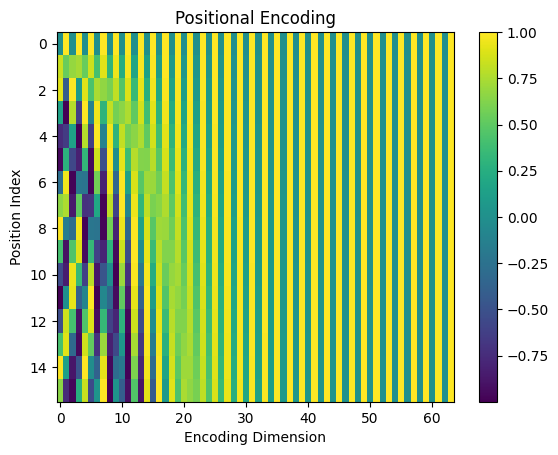

In [14]:
# Illustration Purpose Only
def visualize_pe(pe):
    plt.imshow(pe, aspect="auto")
    plt.title("Positional Encoding")
    plt.xlabel("Encoding Dimension")
    plt.ylabel("Position Index")
    plt.colorbar()
    plt.show()

position_encoding_lookup_table2_np = position_encoding_lookup_table[0].cpu().numpy()
visualize_pe(position_encoding_lookup_table2_np)

In [15]:
# Add positional encoding into the input embedding vector
input_embedding_x = x_batch_embedding + position_encoding_lookup_table # [4, 16, 64] [batch_size, context_length, d_model]
input_embedding_y = y_batch_embedding + position_encoding_lookup_table
pd.DataFrame(input_embedding_x[0].detach().cpu().numpy())

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,1.399742,-0.206918,0.327990,0.748870,0.531874,0.751807,0.351938,0.610762,0.129977,-0.207580,...,-0.547752,2.515671,1.223743,1.833670,-0.404194,1.563555,0.591292,0.275255,1.670105,0.758279
1,1.407957,-0.561974,2.393893,0.377252,1.083746,0.138066,-0.334590,1.670161,0.329176,2.342795,...,0.873984,2.226714,0.794747,1.598629,0.884658,1.032520,1.353795,1.059697,1.172643,1.527427
2,0.482819,1.301215,0.653670,-0.846175,0.628521,1.126829,-0.102938,-0.636202,0.428573,0.553769,...,-0.934116,2.145729,-1.913517,0.552654,0.597746,2.673483,-1.969119,1.397835,-0.438208,0.437077
3,0.851059,0.379319,0.070685,0.910763,-1.117662,0.325378,0.947827,0.472564,0.516017,0.790074,...,0.072798,0.264451,0.070916,-1.744750,1.088080,0.002188,0.715526,-0.357311,1.604357,1.920290
4,-2.720048,-0.354717,0.272903,-0.906938,0.932237,-1.449321,-0.226828,-1.203768,2.488952,2.130765,...,0.533600,0.432145,-2.389682,0.913403,0.066965,1.655225,0.625080,0.236625,-0.692241,0.992275
5,-0.147775,0.718796,0.559903,-0.004127,-0.690035,-0.998508,0.331355,-1.222723,0.836060,-1.353497,...,-0.044886,-0.201054,-0.926252,1.322522,0.587324,1.108183,-1.652407,2.918813,0.942309,1.584330
6,0.038134,3.066611,-1.069607,0.424900,-1.142844,-2.948736,0.505219,-0.617680,1.280667,-0.168857,...,0.202646,1.051821,1.306703,1.517673,0.050767,1.044631,1.347860,0.678610,-0.477987,0.833080
7,-1.368717,2.010294,-1.177933,1.943613,0.931115,-2.610583,-0.812628,-1.958096,2.302625,0.242536,...,-2.336618,1.190780,-0.052987,3.281737,-0.415515,0.198294,-1.392472,2.863094,-0.392633,0.868254
8,3.896336,-0.053480,-1.065470,1.569054,-1.767442,-0.238040,-1.386770,-0.574759,0.118923,-1.069920,...,3.366446,0.203255,1.759607,2.526687,-0.652322,2.660683,0.966853,1.618786,1.664013,2.768385
9,1.811860,-2.118048,0.777184,0.642304,-0.407949,0.093468,-0.256171,-1.183092,0.421236,-2.164224,...,-0.543957,2.515664,1.226589,1.833666,-0.402059,1.563552,0.592893,0.275254,1.671305,0.758279


In [16]:
# Prepare Query, Key, Value for Multi-head Attention
X = input_embedding_x
query = key = value = X # [4, 16, 64] [batch_size, context_length, d_model]
query.shape

torch.Size([4, 16, 64])

In [17]:
# Define Query, Key, Value weight matrices
Wq = nn.Linear(d_model, d_model)
Wk = nn.Linear(d_model, d_model)
Wv = nn.Linear(d_model, d_model)

Q = Wq(query) #[4, 16, 64]
Q = Q.view(batch_size, -1, num_heads, d_model // num_heads)  #[4, 16, 4, 16]

K = Wk(key) #[4, 16, 64]
K = K.view(batch_size, -1, num_heads, d_model // num_heads)  #[4, 16, 4, 16]

V = Wv(value) #[4, 16, 64]
V = V.view(batch_size, -1, num_heads, d_model // num_heads)  #[4, 16, 4, 16]

# print(torch.round(Q[0] * 100) / 100)
qqq = Q.detach().cpu().numpy()
for qs in qqq:
    for qss in qs:
        print(pd.DataFrame(qss))

print(Q.shape) # [4, 16, 4, 16] [batch_size, context_length, num_heads, head_size]

         0         1         2         3         4         5         6         7         8         9         10        11        12        13        14        15
0  0.843055 -0.550052 -0.127732 -0.844840 -0.819225  0.063522 -0.187879  1.182711 -1.542636  0.582238  0.123996 -0.023149  0.141312  0.812356 -1.628145  0.312126
1 -0.350486  0.484634 -0.140094  0.746821  1.481563 -0.266805  0.312059 -0.710153 -0.557109  0.462987 -0.575465  0.824084 -0.910005 -0.060633 -0.851140 -0.696344
2 -0.140998 -0.055692 -0.718412 -0.797249  0.366570  1.513673  0.577341 -0.707247 -0.275017  1.270264 -0.846118 -1.158900  1.652279  0.261800 -0.884520 -0.846511
3 -0.244500  0.759894  0.067822  0.388658 -0.178537  1.044808 -0.276759 -0.887757 -0.158977 -0.619547 -0.298364 -0.604880 -1.250720  0.388842 -1.088377  0.081781
         0         1         2         3         4         5         6         7         8         9         10        11        12        13        14        15
0  0.614938 -0.657467  0.080

In [ ]:
# Transpose q,k,v from [batch_size, context_length, num_heads, head_size] to [batch_size, num_heads, context_length, head_size]
# The reason is that treat each batch with "num_heads" as its first dimension.
Q = Q.transpose(1, 2) # [4, 4, 16, 16]
K = K.transpose(1, 2) # [4, 4, 16, 16]
V = V.transpose(1, 2) # [4, 4, 16, 16]

,0,1,2,3
0,0.827912,-0.240517,-0.580898,0.329683
1,-0.671391,0.753176,0.742822,0.201654
2,0.561314,-0.905538,-0.123649,0.528446
3,-0.523874,-0.022292,-0.313076,0.454725


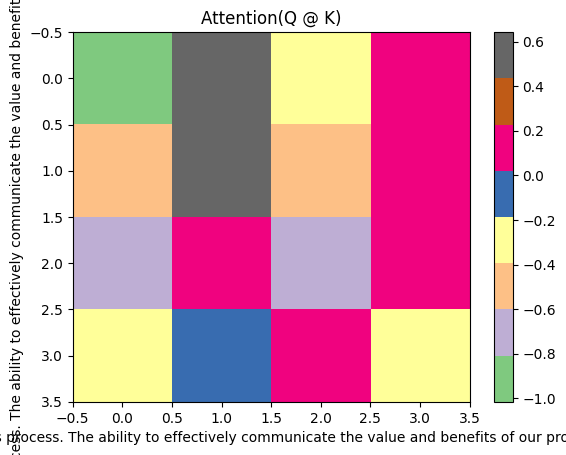

In [18]:
# Calculate the attention score
attention_score = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_model // num_heads) # [4, 4, 16, 16]

# Illustration only
plt.imshow(attention_score[1, 1].detach().cpu().numpy(), "Accent", aspect="auto")
plt.title("Attention(Q @ K)") #plot attention in the first head of the first batch
plt.xlabel(encoding.decode(x_batch[0].tolist()))
plt.ylabel(encoding.decode(x_batch[0].tolist()))
plt.colorbar()
pd.DataFrame(attention_score[0][0].detach().cpu().numpy())

,0,1,2,3
0,0.827912,-inf,-inf,-inf
1,-0.671391,0.753176,-inf,-inf
2,0.561314,-0.905538,-0.123649,-inf
3,-0.523874,-0.022292,-0.313076,0.454725


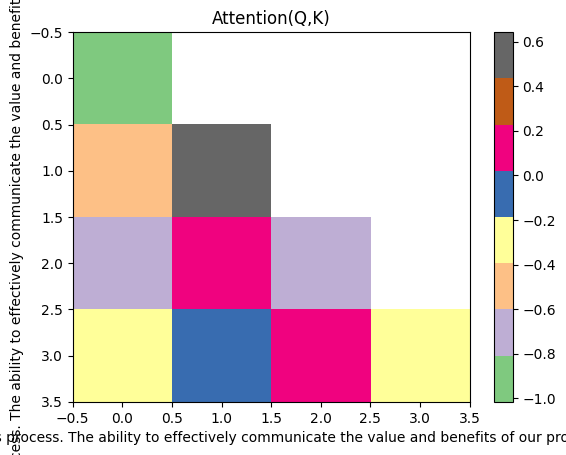

In [19]:
# Apply Mask to attention scores
attention_score = attention_score.masked_fill(torch.triu(torch.ones(attention_score.shape[-2:]), diagonal=1).bool(), float('-inf'))#[4, 4, 16, 16] [batch_size, num_heads, context_length, context_length]

# Illustration only
plt.imshow(attention_score[1, 1].detach().cpu().numpy(), "Accent", aspect="auto")
plt.title("Attention(Q,K)")
plt.xlabel(encoding.decode(x_batch[0].tolist()))
plt.ylabel(encoding.decode(x_batch[0].tolist()))
plt.colorbar()
pd.DataFrame(attention_score[0][0].detach().cpu().numpy())

In [20]:
# Softmax the attention score
attention_score = torch.softmax(attention_score, dim=-1) #[4, 4, 16, 16] [batch_size, num_heads, context_length, context_length]
pd.DataFrame(attention_score[0][0].detach().cpu().numpy())

,0,1,2,3
0,1.000000,0.000000,0.000000,0.000000
1,0.193947,0.806053,0.000000,0.000000
2,0.576449,0.132958,0.290593,0.000000
3,0.152748,0.252238,0.188593,0.406421


In [21]:
# Calculate the V attention output
print(attention_score.shape) #[4, 4, 16, 16] [batch_size, num_heads, context_length, context_length]
print(V.shape) #[4, 4, 16, 16] [batch_size, num_heads, context_length, head_size]
A = torch.matmul(attention_score, V) # [4, 4, 16, 16] [batch_size, num_heads, context_length, head_size]
print(A.shape)

torch.Size([4, 16, 4, 4])
torch.Size([4, 16, 4, 16])
torch.Size([4, 16, 4, 16])


In [22]:
# Concatenate the attention output
A = A.transpose(1, 2) # [4, 16, 4, 16] [batch_size, context_length, num_heads, head_size]
A = A.reshape(batch_size, -1, d_model) # [4, 16, 64] [batch_size, context_length, d_model]
A.shape

torch.Size([4, 16, 64])

In [23]:
# Define the output weight matrix
Wo = nn.Linear(d_model, d_model)
output = Wo(A) # [4, 16, 64] [batch_size, context_length, d_model]
print(output.shape)
pd.DataFrame(output[0].detach().cpu().numpy())

torch.Size([4, 16, 64])


,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,-0.621827,0.543595,-0.666996,-1.283609,-0.001107,-0.042758,-0.215110,-0.413179,-0.520989,0.018130,...,0.454381,0.490832,-0.487829,-0.375702,0.559301,0.453763,-0.260085,-0.020222,-0.377325,0.143832
1,0.759976,-0.019809,0.094721,0.414793,-0.379106,-0.075330,-1.320926,-0.058288,-0.728301,-0.376603,...,0.318793,0.002669,-0.200222,0.641126,-0.055985,0.066465,0.143107,-0.144000,0.610888,0.432793
2,-1.295035,-0.070514,-0.537206,-0.071966,0.426204,0.404068,0.539739,-0.043043,0.175771,-0.183931,...,-0.200597,0.001611,0.318550,0.395115,0.272007,0.445742,-0.122077,0.878259,-0.387794,0.026565
3,0.263409,0.566845,-0.468041,-0.550383,-0.288658,-0.131456,-0.103502,0.119050,-0.052755,-0.554746,...,0.403068,0.117472,-0.214126,0.624904,0.451465,0.136105,0.846148,-0.063243,-0.412568,-0.283516
4,-0.187106,-0.172124,-0.216735,-0.216899,0.200654,0.044692,-0.449638,-1.019850,-0.208834,-0.262261,...,0.172418,0.342270,-0.112124,-0.159100,0.012964,0.387200,-0.281608,0.105357,-0.310467,0.005903
5,0.055683,0.086275,0.205386,0.532015,-0.624699,0.188626,-0.491870,-0.025503,-0.528305,-0.267689,...,0.100602,-0.294130,-0.357328,0.088245,-0.183658,-0.290327,-0.149193,-0.355048,0.642994,0.374485
6,-0.759653,-0.012730,-0.145008,0.164915,0.739590,-0.048068,0.474743,-0.778208,-0.091725,0.103109,...,0.097623,-0.319508,0.655562,0.114698,-0.050315,0.117107,0.351760,0.642871,-0.524488,0.300998
7,0.110556,0.310223,-0.510194,-0.364179,-0.382862,-0.464467,0.193149,-0.013144,-0.172090,-0.337694,...,0.240168,0.092970,-0.170275,0.249586,0.253047,-0.238489,0.371915,-0.203126,-0.458256,-0.399820
8,-0.351318,-0.281024,-0.479323,-0.508772,-0.193866,-0.067695,-0.173200,-0.151622,-0.131757,-0.300368,...,0.195726,0.330997,-0.402337,-0.111817,0.266540,0.400884,-0.388101,-0.290677,-0.192222,0.112107
9,0.248036,0.002887,0.104005,0.330597,-0.414826,-0.007736,-0.698423,-0.060758,-0.396895,-0.632884,...,0.213790,-0.104434,-0.247571,0.126624,0.022858,-0.342605,-0.076128,-0.047415,0.318936,0.023362


In [24]:
# Add residual connection
output = output + X

In [25]:
# Add Layer Normalization
layer_norm = nn.LayerNorm(d_model)
output_layernorm = layer_norm(output)

In [26]:
# Define Feed Forward Network
output = nn.Linear(d_model, d_model * 4)(output_layernorm)
output = nn.ReLU()(output)
output = nn.Linear(d_model * 4, d_model)(output)
output = torch.dropout(output, p=dropout, train=True)

In [27]:
# Add residual connection & layerNorm (last time in a Transformer block)
output = output + output_layernorm
# Add Layer Normalization
layer_norm = nn.LayerNorm(d_model)
output = layer_norm(output)
print(output.shape)

torch.Size([4, 16, 64])


In [28]:
# Until here, we finished a Transformer block,
# We actually should pack the above Transformer block code into a call and
# repeat the steps for num_layers times
# but this jupyter notebook is purely for illustration purpose, so we'll skip it:
# for _ in range(num_layers):
#   do loop for each transformer block

In [29]:
# Apply the final linear layer to get the logits
logits = nn.Linear(d_model, max_token_value+1)(output)
pd.DataFrame(logits[0].detach().cpu().numpy())

,0,1,2,3,4,5,6,7,8,9,...,100060,100061,100062,100063,100064,100065,100066,100067,100068,100069
0,-0.151125,-0.528470,-0.575847,-0.485834,-0.361393,-0.031872,-0.613605,-0.211780,-0.125067,-0.016228,...,0.281603,0.184691,0.802462,0.625889,0.838632,-0.553110,-0.005170,-0.912815,-0.352284,-0.535108
1,-0.064994,0.218902,-0.912383,-0.702425,0.080138,-0.146006,-0.391661,-0.608229,-0.061104,-0.521513,...,0.511191,0.223804,-0.724641,-0.932233,0.782035,-0.403485,0.281639,0.949559,-0.515687,0.407897
2,0.130883,0.259776,-0.050186,-0.393955,-0.311264,-0.456656,0.452273,-0.582056,0.428268,-0.682423,...,0.476942,0.405782,-0.052865,-0.164450,0.754972,-0.351608,-0.341795,-0.834959,-0.702730,-0.462659
3,-0.022134,-0.387955,0.185279,0.408950,-0.354573,0.154944,-0.868895,-0.445031,-1.531363,-1.235431,...,-0.739508,0.922527,0.142801,-0.505968,1.390457,-0.618938,0.161850,0.754036,0.172842,-0.011384
4,-0.211277,-0.437279,0.284793,-0.958420,0.010185,-0.711195,0.269068,-0.087269,-0.069166,-0.067513,...,-0.001751,0.233309,-0.583727,1.732726,0.525236,-0.787924,0.917650,-1.814246,-1.188792,-0.020058
5,-0.084362,-0.182335,-1.300734,-0.076562,-0.421307,-0.532171,-0.815169,0.154031,0.109127,-0.908815,...,-0.653513,0.664641,0.804262,-0.038791,-0.463048,-0.028867,1.004028,-0.692984,-0.047213,0.546382
6,-0.005639,-0.113139,-0.419833,0.245389,0.279896,-0.085587,-1.074004,-0.468869,-0.628933,-0.055460,...,-0.332321,0.531080,0.784389,-0.328390,-0.128384,-1.171888,0.178800,-0.632405,0.724192,-0.778939
7,0.804459,0.011561,0.235016,0.325216,-0.090949,-0.087508,-0.544176,0.737631,0.329875,0.260439,...,0.340776,0.233903,-0.183139,0.060006,0.360331,-0.362391,0.933751,0.473843,0.216209,0.181186
8,0.495570,-0.091035,-0.357877,0.099750,0.442656,-0.194946,-0.613739,0.231858,-0.415880,-0.768998,...,-1.151812,-0.216859,0.464727,0.005435,0.335469,-0.310945,-0.022069,-0.500914,1.519103,-0.054491
9,0.445368,-0.240802,-0.535776,-0.430641,0.807145,-0.588055,-1.001375,0.405754,-0.792283,-0.496802,...,0.065260,0.319446,0.848961,0.362915,0.621657,-0.575843,-0.023330,-0.897608,-0.229748,-0.286087


In [30]:
# Get the probabilities
# torch.softmax usually used during inference, during training we use torch.nn.CrossEntropyLoss
# but for illustration purpose, we'll use torch.softmax here
probabilities = torch.softmax(logits, dim=-1)
pd.DataFrame(probabilities[0].detach().cpu().numpy())


,0,1,2,3,4,5,6,7,8,9,...,100060,100061,100062,100063,100064,100065,100066,100067,100068,100069
0,0.000007,0.000005,0.000005,0.000005,0.000006,0.000008,0.000005,0.000007,0.000007,0.000008,...,0.000011,0.000010,0.000019,0.000016,0.000019,0.000005,0.000008,0.000003,0.000006,0.000005
1,0.000008,0.000010,0.000003,0.000004,0.000009,0.000007,0.000006,0.000005,0.000008,0.000005,...,0.000014,0.000011,0.000004,0.000003,0.000018,0.000006,0.000011,0.000022,0.000005,0.000013
2,0.000010,0.000011,0.000008,0.000006,0.000006,0.000005,0.000013,0.000005,0.000013,0.000004,...,0.000014,0.000013,0.000008,0.000007,0.000018,0.000006,0.000006,0.000004,0.000004,0.000005
3,0.000008,0.000006,0.000010,0.000013,0.000006,0.000010,0.000004,0.000005,0.000002,0.000002,...,0.000004,0.000021,0.000010,0.000005,0.000034,0.000005,0.000010,0.000018,0.000010,0.000008
4,0.000007,0.000005,0.000011,0.000003,0.000009,0.000004,0.000011,0.000008,0.000008,0.000008,...,0.000008,0.000011,0.000005,0.000048,0.000014,0.000004,0.000021,0.000001,0.000003,0.000008
5,0.000008,0.000007,0.000002,0.000008,0.000006,0.000005,0.000004,0.000010,0.000009,0.000003,...,0.000004,0.000016,0.000019,0.000008,0.000005,0.000008,0.000023,0.000004,0.000008,0.000015
6,0.000008,0.000008,0.000006,0.000011,0.000011,0.000008,0.000003,0.000005,0.000005,0.000008,...,0.000006,0.000014,0.000019,0.000006,0.000007,0.000003,0.000010,0.000004,0.000017,0.000004
7,0.000019,0.000009,0.000011,0.000012,0.000008,0.000008,0.000005,0.000018,0.000012,0.000011,...,0.000012,0.000011,0.000007,0.000009,0.000012,0.000006,0.000021,0.000014,0.000010,0.000010
8,0.000014,0.000008,0.000006,0.000009,0.000013,0.000007,0.000005,0.000011,0.000006,0.000004,...,0.000003,0.000007,0.000013,0.000008,0.000012,0.000006,0.000008,0.000005,0.000038,0.000008
9,0.000013,0.000007,0.000005,0.000005,0.000019,0.000005,0.000003,0.000013,0.000004,0.000005,...,0.000009,0.000012,0.000020,0.000012,0.000016,0.000005,0.000008,0.000003,0.000007,0.000006


In [31]:
# Let's see the predicted token and it's original English word
predicted_index = torch.argmax(logits[0,0]).item()
encoding.decode([predicted_index])

' cents'

In [32]:
# Let's see the original input sentence
encoding.decode(x_batch[1].tolist())

' research findings, or industry awards that validate the superiority of your offering. By presenting'

In [ ]:
# Looks like the predicted token "Catholics" is not the correct prediction token to the original sentence, because we only did one training loop and barely trained nothing.
# But this is the basic idea of how the Transformer works.
# We'll continue to train the model in the next notebook and wrap the above code into a class.
# https://waylandzhang.github.io/en/let-s-code-llm.html